# **IMPORTS**

In [ ]:
import nltk
import re
import numpy as np
import tensorflow as tf
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, Lambda, Dense, Flatten
from tensorflow.keras.models import Sequential
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import skipgrams
from tensorflow.keras.layers import Dense, Embedding, Lambda, Reshape

In [ ]:
porter = PorterStemmer()
print(porter.stem("play"))
print(porter.stem("playing"))
print(porter.stem("plays"))
print(porter.stem("played"))
print(porter.stem("Communication"))

play
play
play
play
commun


In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('gutenberg')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


True

In [ ]:
lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize("plays", 'v'))
print(lemmatizer.lemmatize("played", 'v'))
print(lemmatizer.lemmatize("play", 'v'))
print(lemmatizer.lemmatize("playing", 'v'))
print(lemmatizer.lemmatize("Communication", 'v'))


play
play
play
play
Communication


# **Text Preprocessing & Tokenization & CBOW**

In [ ]:
corpus = [
    """*** START OF THE PROJECT GUTENBERG EBOOK 100 *** The Complete Works of William Shakespeare by William Shakespeare
    Contents THE SONNETS ALL’S WELL THAT ENDS WELL THE TRAGEDY OF ANTONY AND CLEOPATRA AS YOU LIKE IT THE COMEDY OF ERRORS
    THE TRAGEDY OF CORIOLANUS CYMBELINE THE TRAGEDY OF HAMLET, PRINCE OF DENMARK THE FIRST PART OF KING HENRY THE FOURTH
    THE SECOND PART OF KING HENRY THE FOURTH THE LIFE OF KING HENRY THE FIFTH THE FIRST PART OF HENRY THE SIXTH
    THE SECOND PART OF KING HENRY THE SIXTH THE THIRD PART OF KING HENRY THE SIXTH KING HENRY THE EIGHTH..."""
]

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = word_tokenize(text)  # Tokenize
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
processed_corpus = [preprocess_text(sentence) for sentence in corpus]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(processed_corpus)
sequences = tokenizer.texts_to_sequences(processed_corpus)
print("Processed Corpus:", processed_corpus)
print("Word Index Mapping:", tokenizer.word_index)
print("Sequences:", sequences)


Processed Corpus: ['start project gutenberg ebook 100 complete works william shakespeare william shakespeare contents sonnets alls well ends well tragedy antony cleopatra like comedy errors tragedy coriolanus cymbeline tragedy hamlet prince denmark first part king henry fourth second part king henry fourth life king henry fifth first part henry sixth second part king henry sixth third part king henry sixth king henry eighth']
Word Index Mapping: {'henry': 1, 'king': 2, 'part': 3, 'tragedy': 4, 'sixth': 5, 'william': 6, 'shakespeare': 7, 'well': 8, 'first': 9, 'fourth': 10, 'second': 11, 'start': 12, 'project': 13, 'gutenberg': 14, 'ebook': 15, '100': 16, 'complete': 17, 'works': 18, 'contents': 19, 'sonnets': 20, 'alls': 21, 'ends': 22, 'antony': 23, 'cleopatra': 24, 'like': 25, 'comedy': 26, 'errors': 27, 'coriolanus': 28, 'cymbeline': 29, 'hamlet': 30, 'prince': 31, 'denmark': 32, 'life': 33, 'fifth': 34, 'third': 35, 'eighth': 36}
Sequences: [[12, 13, 14, 15, 16, 17, 18, 6, 7, 6, 7,

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
def generate_cbow_training_data(sequences, window_size):
    contexts, targets = [], []
    for sequence in sequences:
        for i in range(window_size, len(sequence) - window_size):
            context = sequence[i - window_size:i] + sequence[i + 1:i + window_size + 1]
            target = sequence[i]
            contexts.append(context)
            targets.append(target)
    return np.array(contexts), tf.keras.utils.to_categorical(targets, num_classes=vocab_size)

window_size = 2
X_cbow, y_cbow = generate_cbow_training_data(sequences, window_size)

In [ ]:
cbow_model = Sequential([
    Embedding(vocab_size, 50, input_length=2 * window_size),
    Lambda(lambda x: tf.reduce_mean(x, axis=1)),
    Dense(vocab_size, activation='softmax')
])
cbow_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cbow_model.fit(X_cbow, y_cbow, epochs=10, verbose=1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.0455 - loss: 3.6101
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1014 - loss: 3.6025 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1795 - loss: 3.5948 
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2250 - loss: 3.5869
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3043 - loss: 3.5789 
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4278 - loss: 3.5719 
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4499 - loss: 3.5648
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4929 - loss: 3.5554
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5475 - loss: 3.5474
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5384 - loss: 3.5405


# **GENERATE SKIP-GRAM PAIRS**

In [ ]:
def generate_skipgram_training_data(sequences, window_size):
    skip_gram_pairs = []
    for sequence in sequences:
        for i in range(window_size, len(sequence) - window_size):
            target = sequence[i]
            context_words = sequence[i - window_size:i] + sequence[i + 1:i + window_size + 1]
            for context_word in context_words:
                skip_gram_pairs.append((target, context_word))
    return zip(*skip_gram_pairs)

X_skipgram, y_skipgram = generate_skipgram_training_data(sequences, window_size)
X_skipgram = np.array(X_skipgram)
y_skipgram = tf.keras.utils.to_categorical(y_skipgram, num_classes=vocab_size)

skipgram_model = Sequential([
    Embedding(vocab_size, 50, input_length=1),
    Flatten(),
    Dense(vocab_size, activation='softmax')
])
skipgram_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
skipgram_model.fit(X_skipgram, y_skipgram, epochs=10, verbose=1)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0617 - loss: 3.6055  
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1217 - loss: 3.5866 
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1196 - loss: 3.5703 
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1827 - loss: 3.5567 
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2236 - loss: 3.5375 
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2369 - loss: 3.5191 
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2348 - loss: 3.5054 
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2177 - loss: 3.4858 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2495 - loss: 3.4612 
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3110 - loss: 3.4328  


# **Extract embeddings**

In [ ]:
def get_embedding_matrix(model):
    return model.layers[0].get_weights()[0]

def find_similar_words(word, embeddings, tokenizer, top_n=10):
    if word not in tokenizer.word_index:
        return []
    word_vec = embeddings[tokenizer.word_index[word]].reshape(1, -1)
    similarities = [
        (other_word, cosine_similarity(word_vec, embeddings[idx].reshape(1, -1))[0][0])
        for other_word, idx in tokenizer.word_index.items()
    ]
    return sorted(similarities, key=lambda x: x[1], reverse=True)[1:top_n+1]

def plot_embeddings(embeddings, tokenizer):
    words = list(tokenizer.word_index.keys())[:30]  # Take first 30 words
    word_vectors = np.array([embeddings[tokenizer.word_index[word]] for word in words])
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(word_vectors)

    plt.figure(figsize=(10, 5))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))
    plt.show()

In [ ]:
cbow_embeddings = get_embedding_matrix(cbow_model)
skipgram_embeddings = get_embedding_matrix(skipgram_model)

CBOW vs. Skip-Gram Embeddings:


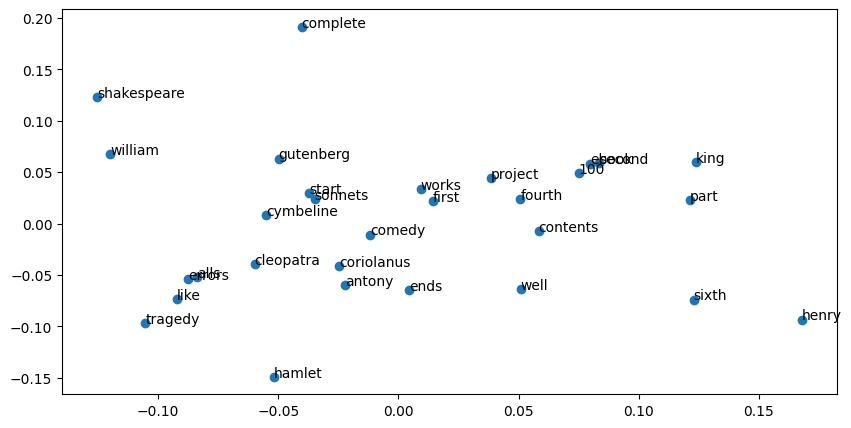

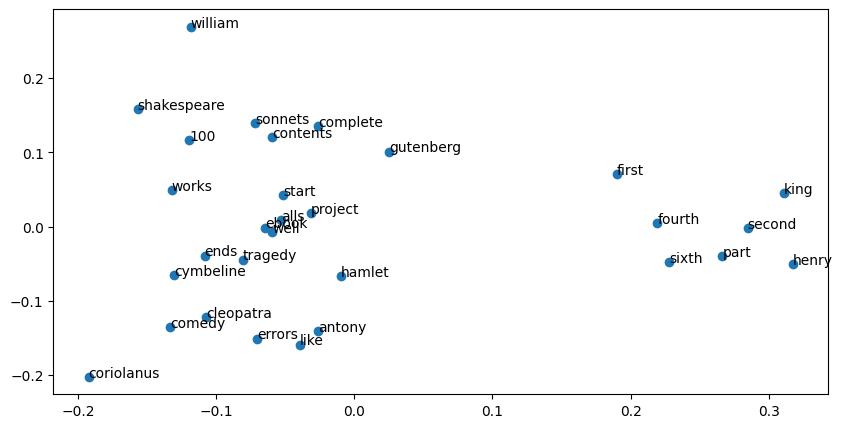

In [ ]:
print("CBOW vs. Skip-Gram Embeddings:")
plot_embeddings(cbow_embeddings, tokenizer)
plot_embeddings(skipgram_embeddings, tokenizer)

In [ ]:
print("Similar words to 'shakespeare' in CBOW:")
print(find_similar_words("shakespeare", cbow_embeddings, tokenizer))

Similar words to 'shakespeare' in CBOW:
[('complete', 0.33888632), ('william', 0.3187873), ('sonnets', 0.30619085), ('cymbeline', 0.21044433), ('alls', 0.14573634), ('fourth', 0.09462754), ('gutenberg', 0.08048651), ('ends', 0.070304), ('second', 0.04369646), ('first', 0.03399991)]


In [ ]:
print("Similar words to 'shakespeare' in Skip-Gram:")
print(find_similar_words("shakespeare", skipgram_embeddings, tokenizer))

Similar words to 'shakespeare' in Skip-Gram:
[('william', 0.5381431), ('contents', 0.45526913), ('sonnets', 0.44956145), ('complete', 0.3484868), ('start', 0.31182775), ('works', 0.28313738), ('tragedy', 0.26962748), ('well', 0.1850309), ('100', 0.15954144), ('cleopatra', 0.1576494)]


In [ ]:

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 37
